## This notebook contains codes executed to implement and analyze two GAN variants (Task1: WGAN-GP and Task2: Conditional WGAN-GP) on CelebA.

# Task 1 — WGAN-GP on CelebA 64×64

**Source code lives on GitHub — cloned automatically in Section 2.**

**Outputs written to** `./outputs/` (inside the cloned repo):
```
checkpoints/          model weights per epoch
samples/              periodic grids + samples_final_50.png + interpolation.png
training_curves.png   3-panel loss plot
losses.json           raw loss history
```

## 1 · Environment setup

In [ ]:
# Verify GPU is available
import torch
print('PyTorch :', torch.__version__)
print('CUDA    :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU     :', torch.cuda.get_device_name(0))
    print('VRAM    :', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')

PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB


In [ ]:
# Install dependencies from requirements.txt (cloned in the next section)
# Run this cell AFTER cloning, or manually install here as a fallback:
!pip install -q torch torchvision matplotlib numpy

## 2 · Clone from GitHub & install dependencies

In [ ]:
import os, sys

GITHUB_REPO = 'https://github.com/mehrosejaved/gan_variants.git'


REPO_NAME   = GITHUB_REPO.rstrip('/').split('/')[-1].replace('.git', '')
CLONE_DIR   = f'/content/{REPO_NAME}'
TASK1_DIR   = os.path.join(CLONE_DIR, 'wgan_gp')

# Clone
if not os.path.exists(CLONE_DIR):
    os.system(f'git clone {GITHUB_REPO} {CLONE_DIR}')
    print(f'Cloned → {CLONE_DIR}')
else:
    os.system(f'git -C {CLONE_DIR} pull')
    print(f'Pulled latest → {CLONE_DIR}')

# Install dependencies
os.system(f'pip install -q -r {TASK1_DIR}/requirements.txt')

# Point Python at the wgan_gp subfolder so `import dataset` etc. work
sys.path.insert(0, TASK1_DIR)
os.chdir(TASK1_DIR)
print('Working dir:', os.getcwd())
print('Files      :', os.listdir('.'))

Pulled latest → /content/gan_variants
Working dir: /content/gan_variants/wgan_gp
Files      : ['wgan_gp_task1.ipynb', 'dataset.py', 'utils.py', 'train.py', 'requirements.txt', 'models.py']


In [ ]:
# Check file structure
import os

for root, dirs, files in os.walk('.', topdown=True):
    for name in files:
        if 'dataset' in name.lower():
            print(os.path.join(root, name))

./dataset.py


In [ ]:
# Optional:
# To save outputs back to GitHub during/after training:
#   import os
#   os.system('git add outputs/ && git commit -m "training run" && git push')

## 3 · CelebA dataset setup

In [ ]:
# Download from Kaggle, unzip and store in data folder
!kaggle datasets download -d jessicali9530/celeba-dataset -p ./data --unzip

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [00:08<00:00, 159MB/s]



In [ ]:
DATA_ROOT = './data'
print('DATA_ROOT:', DATA_ROOT)

DATA_ROOT: ./data


In [ ]:
# Quick loader sanity check — should print (B,3,64,64) and range ~ [-1, 1]
from dataset import get_celeba_loader

loader = get_celeba_loader(
    root=DATA_ROOT,
    split='train',
    batch_size=16,
    num_workers=2,
    max_samples=512,   # small for this check only
)
batch = next(iter(loader))
print('Batch shape :', batch.shape)
print('Value range :', batch.min().item(), '→', batch.max().item())
print('Dataset size:', len(loader.dataset), 'images')

[KaggleCelebA] images    : data/img_align_celeba/img_align_celeba
[KaggleCelebA] attrs     : data/list_attr_celeba.csv
[KaggleCelebA] partition : data/list_eval_partition.csv
[KaggleCelebA] split='train' → 162,770 images
Batch shape : torch.Size([16, 3, 64, 64])
Value range : -1.0 → 1.0
Dataset size: 512 images


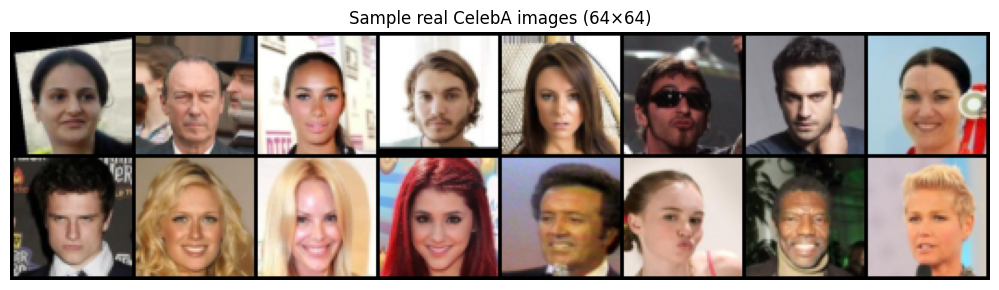

In [ ]:
# Visualise a batch of real images
import torchvision.utils as vutils
import matplotlib.pyplot as plt

grid = vutils.make_grid(batch[:16], nrow=8, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(12, 3))
plt.axis('off')
plt.title('Sample real CelebA images (64×64)')
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.tight_layout()
plt.show()

## 4 · Model sanity check

In [ ]:
import torch
from models import Generator, Critic, weights_init
from utils  import gradient_penalty

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

LATENT_DIM   = 128
FEATURE_MAPS = 64

G = Generator(latent_dim=LATENT_DIM, feature_maps=FEATURE_MAPS).to(device)
D = Critic(feature_maps=FEATURE_MAPS).to(device)
G.apply(weights_init)
D.apply(weights_init)

z    = torch.randn(8, LATENT_DIM, device=device)
fake = G(z)
real = torch.randn(8, 3, 64, 64, device=device)   # dummy
gp   = gradient_penalty(D, real, fake.detach(), device)

print(f'G output : {fake.shape}  range [{fake.min():.2f}, {fake.max():.2f}]')
print(f'D output : {D(fake).shape}')
print(f'GP value : {gp.item():.4f}')
print(f'G params : {sum(p.numel() for p in G.parameters()):,}')
print(f'D params : {sum(p.numel() for p in D.parameters()):,}')

G output : torch.Size([8, 3, 64, 64])  range [-0.76, 0.78]
D output : torch.Size([8])
GP value : 109.6031
G params : 3,806,080
D params : 2,765,568


## 5 · Training configuration

In [ ]:
from train import Config

cfg = Config(
    data_root      = DATA_ROOT,
    max_samples    = None,       # None = full CelebA (~162k); set e.g. 50_000 on free tier
    latent_dim     = 128,
    feature_maps   = 64,
    num_epochs     = 20,
    batch_size     = 64,
    n_critic       = 5,
    lambda_gp      = 10.0,
    lr             = 1e-4,
    adam_b1        = 0.0,
    adam_b2        = 0.9,
    output_dir     = './outputs',
    sample_interval= 200,        # save sample grid every 200 G-steps
    ckpt_interval  = 5,          # checkpoint every 5 epochs
    num_workers    = 2,
    seed           = 42,
)
print(cfg)

Config(data_root='./data', max_samples=None, latent_dim=128, feature_maps=64, num_epochs=20, batch_size=64, n_critic=5, lambda_gp=10.0, lr=0.0001, adam_b1=0.0, adam_b2=0.9, output_dir='./outputs', sample_interval=200, ckpt_interval=5, num_workers=2, seed=42)


## 6 · Run training

In [ ]:
from train import train

# To resume from a checkpoint:
#   train(cfg, resume_from='./outputs/checkpoints/ckpt_epoch005.pt')

train(cfg, resume_from=None)

Device  : cuda
Epochs  : 20  |  Batch : 64  |  n_critic : 5
[KaggleCelebA] images    : data/img_align_celeba/img_align_celeba
[KaggleCelebA] attrs     : data/list_attr_celeba.csv
[KaggleCelebA] partition : data/list_eval_partition.csv
[KaggleCelebA] split='train' → 162,770 images
Dataset : 162,770 images  →  2,543 batches/epoch
G params: 3,806,080
D params: 2,765,568
Epoch [001/20]  Step    50  |  D: -16.9977  G: +10.2965  GP: 0.4421  W-dist: +21.4187
Epoch [001/20]  Step   100  |  D: -15.8105  G: +9.4807  GP: 0.3163  W-dist: +18.9738
Epoch [001/20]  Step   150  |  D: -13.7658  G: +15.4814  GP: 0.3317  W-dist: +17.0829
[save_image_grid] saved → outputs/samples/grid_000200.png
Epoch [001/20]  Step   200  |  D: -13.0475  G: +21.6263  GP: 0.2563  W-dist: +15.6109
Epoch [001/20]  Step   250  |  D: -14.7306  G: +25.8121  GP: 0.2608  W-dist: +17.3384
Epoch [001/20]  Step   300  |  D: -13.8955  G: +27.6748  GP: 0.3705  W-dist: +17.6007
Epoch [001/20]  Step   350  |  D: -15.0268  G: +28.4205  

## 7 · Training curves

Total G steps recorded: 10172
[plot_training_curves] saved → outputs/training_curves.png


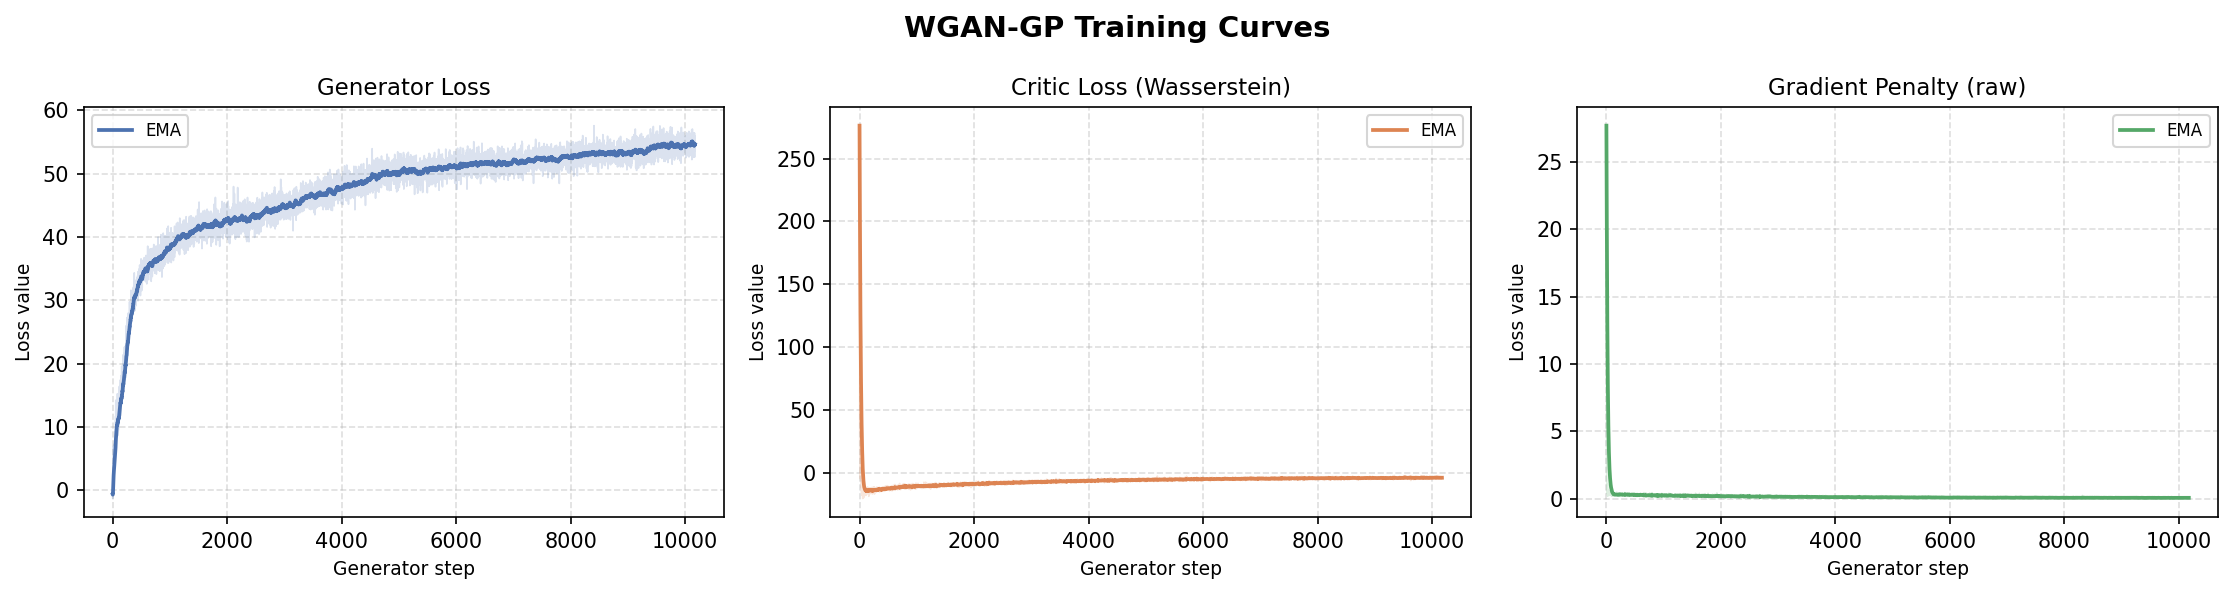

In [ ]:
from utils import LossTracker, plot_training_curves
import matplotlib.pyplot as plt
from IPython.display import Image as IPImage, display

# Reload from JSON in case the training cell was re-run
tracker = LossTracker.load('./outputs/losses.json')
print(f'Total G steps recorded: {len(tracker)}')

# Re-render the 3-panel figure inline
plot_training_curves(
    tracker,
    save_path='./outputs/training_curves.png',
    show=False,      # we display below
    ema_alpha=0.05,
)
display(IPImage('./outputs/training_curves.png'))

## 8 · 50 generated samples (report grid)

In [ ]:
%matplotlib inline

import torch, matplotlib.pyplot as plt
import torchvision.utils as vutils
from models import Generator

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the final checkpoint
import glob, os
ckpts = sorted(glob.glob('./outputs/checkpoints/ckpt_epoch*.pt'))
print('Available checkpoints:', [os.path.basename(c) for c in ckpts])

G = Generator(latent_dim=cfg.latent_dim, feature_maps=cfg.feature_maps).to(device)
ckpt = torch.load(ckpts[-1], map_location=device)   # latest checkpoint
G.load_state_dict(ckpt['G'])
G.eval()
print(f'Loaded: {os.path.basename(ckpts[-1])}')

with torch.no_grad():
    z50   = torch.randn(50, cfg.latent_dim, device=device)
    imgs  = G(z50)

grid = vutils.make_grid(imgs, nrow=10, normalize=True, value_range=(-1, 1), padding=2)

plt.figure(figsize=(18, 9))
plt.axis('off')
plt.title('50 Generated CelebA Samples — WGAN-GP', fontsize=14)
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.tight_layout()
plt.savefig('./outputs/samples/samples_final_50.png', dpi=150, bbox_inches='tight')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 9 · Latent interpolation (≥ 8 intermediate steps)

[save_image_grid] saved → ./outputs/samples/interpolation.png
  [interp] saved 12-frame interpolation → ./outputs/samples/interpolation.png


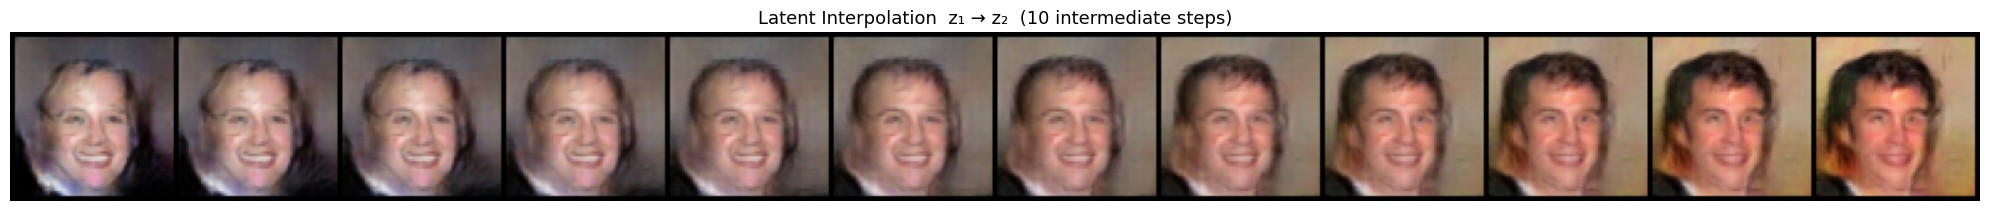

In [ ]:
%matplotlib inline

import torch, matplotlib.pyplot as plt
import torchvision.utils as vutils
from train import latent_interpolation

# G should still be loaded from the previous cell
latent_interpolation(
    G,
    device=device,
    latent_dim=cfg.latent_dim,
    n_steps=10,              # 10 intermediate + 2 endpoints = 12 frames
    save_path='./outputs/samples/interpolation.png',
    seed=cfg.seed,
)

interp = plt.imread('./outputs/samples/interpolation.png')
plt.figure(figsize=(20, 3))
plt.axis('off')
plt.title('Latent Interpolation  z₁ → z₂  (10 intermediate steps)', fontsize=13)
plt.imshow(interp)
plt.tight_layout()
plt.show()

## 10 · Browse periodic sample grids
Useful for spotting when the generator started producing coherent faces.

In [ ]:
%matplotlib inline

import glob, os
import matplotlib.pyplot as plt

grids = sorted(glob.glob('./outputs/samples/grid_*.png'))
print(f'Found {len(grids)} periodic grids')

# Show every 5th grid to keep the notebook compact
show_grids = grids[::5] if len(grids) > 5 else grids

fig, axes = plt.subplots(1, len(show_grids), figsize=(5 * len(show_grids), 5))
if len(show_grids) == 1:
    axes = [axes]
for ax, path in zip(axes, show_grids):
    step = os.path.basename(path).replace('grid_', '').replace('.png', '')
    ax.imshow(plt.imread(path))
    ax.set_title(f'step {int(step):,}', fontsize=9)
    ax.axis('off')
plt.suptitle('Generator progress over training', fontsize=12)
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 11 · Download all outputs as a zip

In [ ]:
# Zip the outputs folder and download it locally
import shutil
shutil.make_archive('wgan_gp_outputs', 'zip', './outputs')

from google.colab import files
files.download('wgan_gp_outputs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>